In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('Reviews_cleaned.csv')
print(df.columns.tolist())
print(df.shape)

['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'review_length', 'helpfulness_ratio', 'Year', 'refined_text']
(393579, 14)


sentiment
1    306758
0     57067
Name: count, dtype: int64

Total reviews after dropping 3-star: 363825


C:\Users\pragy\AppData\Local\Temp\ipykernel_14232\4083525722.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


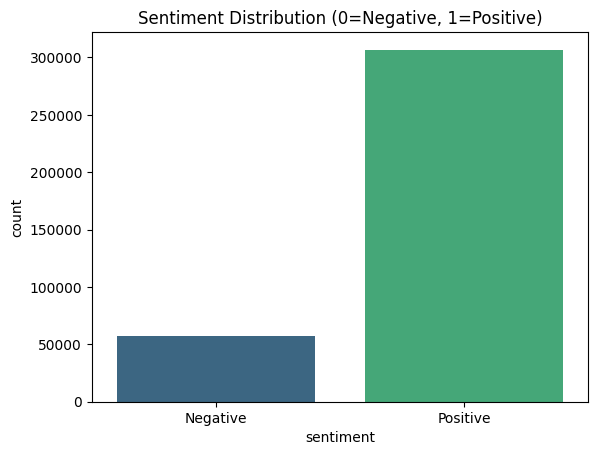

In [2]:
# Drop neutral reviews (score 3)
df = df[df['Score'] != 3]

# Create binary sentiment labels
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

# Check balance
print(df['sentiment'].value_counts())
print(f"\nTotal reviews after dropping 3-star: {len(df)}")

# Visualise
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution (0=Negative, 1=Positive)')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

In [3]:
print(f"NaN in cleaned_text: {df['refined_text'].isna().sum()}")

NaN in cleaned_text: 4


In [4]:
df['refined_text'] = df['refined_text'].fillna('')
df = df[df['refined_text'].str.strip() != '']

print(f"Shape after fix: {df.shape}")

Shape after fix: (363821, 15)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df['refined_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model_lr = LogisticRegression(   
    class_weight='balanced',  # handles 84/16 imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42)
model_lr.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

What this does:

TF-IDF = Term Frequency × Inverse Document Frequency — gives higher weight to words that are frequent in a review but rare across all reviews
ngram_range=(1,2) captures both single words ("good") and phrases ("not good") — critical for sentiment
fit_transform on training only — we never fit on test data to avoid data leakage

Perfect ✅ That means:

Every column represents a word or two-word phrase
The matrix is sparse — mostly zeros (most words don't appear in most reviews)

What this does: Trains a Logistic Regression model on the TF-IDF vectors. Despite being a "simple" model, Logistic Regression on TF-IDF is surprisingly powerful for text classification and is used in production at many companies.

Accuracy: 0.8825

Classification Report:
              precision    recall  f1-score   support

    Negative       0.58      0.88      0.70     11455
    Positive       0.97      0.88      0.93     61310

    accuracy                           0.88     72765
   macro avg       0.78      0.88      0.81     72765
weighted avg       0.91      0.88      0.89     72765



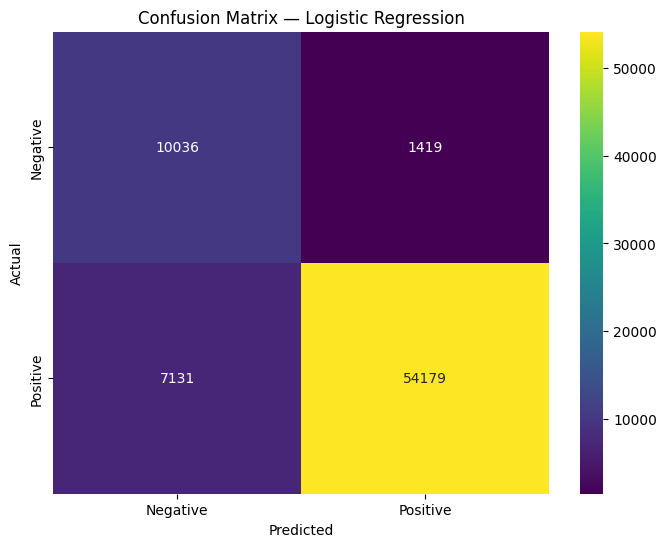

In [6]:
# Make predictions
y_pred = model_lr.predict(X_test_tfidf)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = model_lr.coef_[0]

# Top 15 words for each sentiment
top_positive_idx = coefficients.argsort()[-15:][::-1]
top_negative_idx = coefficients.argsort()[:15]

print("Top 15 words → POSITIVE sentiment:")
for idx in top_positive_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

print("\nTop 15 words → NEGATIVE sentiment:")
for idx in top_negative_idx:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

Top 15 words → POSITIVE sentiment:
  great: 11.804
  delicious: 11.294
  perfect: 10.213
  good: 8.986
  love: 8.722
  highly recommend: 8.686
  awesome: 8.449
  excellent: 8.424
  amazing: 8.231
  wonderful: 7.795
  pleased: 7.247
  hook: 7.181
  fantastic: 7.053
  yummy: 6.963
  beat: 6.683

Top 15 words → NEGATIVE sentiment:
  disappointing: -10.789
  disappointed: -10.497
  terrible: -9.834
  disappointment: -9.771
  awful: -9.498
  unfortunately: -7.847
  horrible: -7.840
  return: -7.307
  tasteless: -7.276
  cancel: -7.164
  bland: -6.981
  refund: -6.823
  disgusting: -6.801
  sorry: -6.549
  yuck: -6.444


In [8]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC()
model_svm.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['refined_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df['vader_label'] = df['vader_score'].apply(
    lambda x: 1 if x > 0.05 else (0 if x < -0.05 else -1)
)

In [10]:
print(df['vader_label'].value_counts())

vader_label
 1    331918
 0     24669
-1      7234
Name: count, dtype: int64


In [11]:
mismatch = df[df['sentiment'] != df['vader_label']]

print("Mismatch count:", len(mismatch))
print("Mismatch %:", len(mismatch) / len(df) * 100)

Mismatch count: 53963
Mismatch %: 14.832293902770868


SVM Accuracy: 0.9222565793994365

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.66      0.73     11455
           1       0.94      0.97      0.95     61310

    accuracy                           0.92     72765
   macro avg       0.88      0.82      0.84     72765
weighted avg       0.92      0.92      0.92     72765



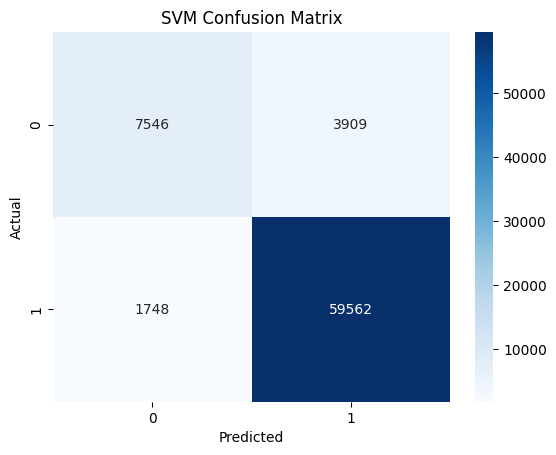

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_svm = model_svm.predict(X_test_tfidf)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

# Classification report
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

VADER Accuracy: 0.8522778808493094

VADER Classification Report:
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         0
           0       0.66      0.29      0.40     11455
           1       0.89      0.96      0.92     61310

    accuracy                           0.85     72765
   macro avg       0.51      0.42      0.44     72765
weighted avg       0.85      0.85      0.84     72765



C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

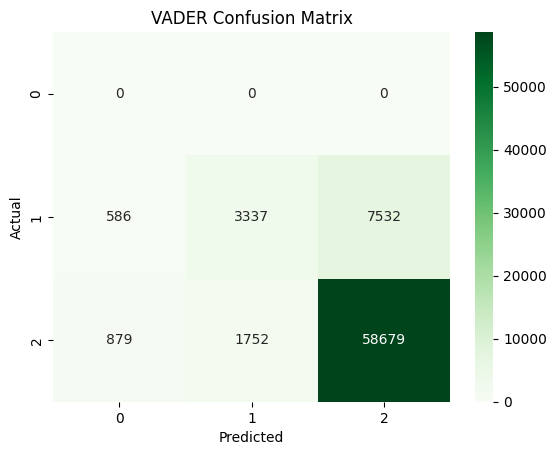

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Align with test set
df_test = df.loc[y_test.index]

y_true = df_test['sentiment']
y_pred_vader = df_test['vader_label']

# Accuracy
print("VADER Accuracy:", accuracy_score(y_true, y_pred_vader))

# Classification report
print("\nVADER Classification Report:")
print(classification_report(y_true, y_pred_vader))

# Confusion matrix
cm_vader = confusion_matrix(y_true, y_pred_vader)

sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Greens')
plt.title("VADER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
df_eval = df.copy()

# Remove neutral VADER
df_eval = df_eval[df_eval['vader_label'] != -1]

In [15]:
df_test = df_eval.loc[df_eval.index.intersection(y_test.index)]

y_true = df_test['sentiment']
y_pred_vader = df_test['vader_label']

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

# ----------- Logistic Regression -----------
report_lr = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)
df_lr = pd.DataFrame(report_lr).transpose()
df_lr['Model'] = 'Logistic Regression'

# ----------- SVM -----------
report_svm = classification_report(y_test, y_pred_svm, target_names=['Negative', 'Positive'], output_dict=True)
df_svm = pd.DataFrame(report_svm).transpose()
df_svm['Model'] = 'SVM'

# ----------- VADER -----------
report_vader = classification_report(y_true, y_pred_vader, target_names=['Negative', 'Positive'], output_dict=True)
df_vader = pd.DataFrame(report_vader).transpose()
df_vader['Model'] = 'VADER'

# ----------- Combine all -----------
df_combined = pd.concat([df_lr, df_svm, df_vader])

# Clean format
df_combined = df_combined.reset_index().rename(columns={'index': 'Class'})

print(df_combined)

           Class  precision    recall  f1-score       support  \
0       Negative   0.584610  0.876124  0.701279  11455.000000   
1       Positive   0.974477  0.883689  0.926866  61310.000000   
2       accuracy   0.882498  0.882498  0.882498      0.882498   
3      macro avg   0.779544  0.879907  0.814072  72765.000000   
4   weighted avg   0.913103  0.882498  0.891353  72765.000000   
5       Negative   0.811922  0.658752  0.727360  11455.000000   
6       Positive   0.938413  0.971489  0.954665  61310.000000   
7       accuracy   0.922257  0.922257  0.922257      0.922257   
8      macro avg   0.875167  0.815120  0.841012  72765.000000   
9   weighted avg   0.918500  0.922257  0.918881  72765.000000   
10      Negative   0.655728  0.307020  0.418223  10869.000000   
11      Positive   0.886242  0.971008  0.926691  60431.000000   
12      accuracy   0.869790  0.869790  0.869790      0.869790   
13     macro avg   0.770985  0.639014  0.672457  71300.000000   
14  weighted avg   0.8511

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW
from sklearn.metrics import classification_report
import numpy as np

# ── 1. Setup ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── 2. Sample data (full dataset too large for CPU) ───────────
df_bert = df[df['Score'] != 3].copy()
df_bert['sentiment'] = df_bert['Score'].apply(lambda x: 1 if x >= 4 else 0)

# Sample 20K for training — enough for DistilBERT to learn well
df_sample = df_bert.sample(n=20000, random_state=42)

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df_sample, test_size=0.2, 
    random_state=42, 
    stratify=df_sample['sentiment']
)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
# ── 3. Tokenizer ──────────────────────────────────────────────
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Use RAW text for BERT — it handles its own tokenization
train_dataset = ReviewDataset(
    train_df['Text'], train_df['sentiment'], tokenizer
)
test_dataset = ReviewDataset(
    test_df['Text'], test_df['sentiment'], tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print("Datasets ready!")
# ── 4. Load DistilBERT Model ──────────────────────────────────
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

print("Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
# ── 5. Training Loop ──────────────────────────────────────────
epochs = 2  # 2 is enough for fine-tuning

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"\nEpoch {epoch+1} complete | Avg Loss: {avg_loss:.4f}\n")

print("Training complete!")
# ── 6. Evaluation ─────────────────────────────────────────────
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("DistilBERT Results:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Negative', 'Positive']
))

C:\Users\pragy\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

KeyboardInterrupt



just was implementing distilbert above because of time and gpu limitationswas not implemented

In [21]:
df.to_csv('Reviews_sentiment.csv', index=False)
print("Saved!")
print(df.shape)

Saved!
(364163, 18)


In [19]:
df.to_csv('Reviews_sentiment.csv', index=False)
print("Saved!")
print(df.shape)

Saved!
(363821, 17)


In [20]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'review_length', 'helpfulness_ratio', 'Year', 'refined_text',
       'sentiment', 'vader_score', 'vader_label'],
      dtype='object')